# Q3: ER Stress, Reactive Glia, and Panglial Network Disruption

This notebook asks whether ER stress signatures in oligodendrocytes and reactive glial states (microglia, A1 astrocytes) are associated with disruption of the panglial connexin network early after demyelination, and whether these signals decline as Cx47 recovers during remyelination.

**Primary dataset:** Jäkel et al. (human MS snRNA-seq, `jakel_et_al.h5ad`)  
**Secondary dataset:** Falcao et al. (EAE + MS scRNA-seq, `falcao_et_al.h5ad`)  
**Progression axis:** Lesion class (Ctrl → NAWM → A → CA → CI → RM) in Jäkel; `stage` in Falcao  

**Key panels per cell compartment:**
- Oligodendrocytes: `er_stress_upr`, `panglial_connexins`, `oligodendrocyte_identity`
- Microglia: `microglial_activation`, `inflammatory_cytokines`
- Astrocytes: `a1_reactive_astrocytes`, `ion_homeostasis`

In [2]:
from pathlib import Path
import os
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from IPython.display import Markdown, display

CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(
    (p for p in CANDIDATES if (p / "src").exists() and (p / "config").exists()), None
)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root.")

MPL_CACHE_DIR = REPO_ROOT / ".cache" / "matplotlib"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from cx47_oligo.gene_panels import GENE_PANELS
from cx47_oligo.exports import ensure_results_dir, save_current_figure, save_json, save_table
from cx47_oligo.h5ad_tools import (
    adata_overview,
    expression_frame,
    load_h5ad,
    obs_column_summary,
    panel_availability_table,
    resolve_gene_symbols,
    score_gene_panel,
)
from cx47_oligo.scanpy_tools import grouped_gene_expression_stats, obs_keyword_mask

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fbfcfd",
    "axes.edgecolor": "#d7dde2",
    "grid.color": "#dde4ea",
    "grid.alpha": 0.75,
})

In [3]:
DATASET_PATH = REPO_ROOT / "data" / "raw" / "jakel_et_al.h5ad"
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing: {DATASET_PATH}")

RESULTS_DIR = ensure_results_dir(REPO_ROOT, "03_er_stress_reactive_glia", DATASET_PATH)
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CELLTYPE_COLUMN = "Celltypes"
LESION_COLUMN = "Lesion"
SAMPLE_COLUMN = "Sample"
LESION_ORDER = ["Ctrl", "NAWM", "A", "CA", "CI", "RM"]

CONNEXIN_GENES = ["GJC2", "GJB1", "GJA1"]

OLIGO_PANELS   = ["er_stress_upr", "oligodendrocyte_identity", "panglial_connexins"]
MICROGLIA_PANELS = ["microglial_activation", "inflammatory_cytokines"]
ASTRO_PANELS   = ["a1_reactive_astrocytes", "ion_homeostasis", "astrocyte_identity"]
ALL_PANELS = list(dict.fromkeys(OLIGO_PANELS + MICROGLIA_PANELS + ASTRO_PANELS))

print("Dataset:", DATASET_PATH)
print("Results:", RESULTS_DIR)

Dataset: /Users/chrislangseth/work/karolinska_institutet/projects/cx47-oligo/data/raw/jakel_et_al.h5ad
Results: /Users/chrislangseth/work/karolinska_institutet/projects/cx47-oligo/results/03_er_stress_reactive_glia/jakel_et_al


In [4]:
adata = load_h5ad(DATASET_PATH)
display(adata_overview(adata))

# Ordered lesion category
present_lesions = set(adata.obs[LESION_COLUMN].astype(str).unique())
LESION_ORDER_PRESENT = [l for l in LESION_ORDER if l in present_lesions]
adata.obs["Lesion_ordered"] = pd.Categorical(
    adata.obs[LESION_COLUMN].astype(str),
    categories=LESION_ORDER_PRESENT,
    ordered=True,
)

meta_cols = [c for c in [CELLTYPE_COLUMN, LESION_COLUMN, SAMPLE_COLUMN, "Condition"] if c in adata.obs.columns]
display(obs_column_summary(adata).loc[lambda df: df["column"].isin(meta_cols)])

coverage = panel_availability_table(adata, ALL_PANELS)
display(coverage)
save_table(coverage, RESULTS_DIR / "panel_coverage.csv", index=False)

# Cell-type subsets
oligo_mask   = obs_keyword_mask(adata, CELLTYPE_COLUMN, ["oligo", "opc", "cop", "imolg"])
astro_mask   = obs_keyword_mask(adata, CELLTYPE_COLUMN, ["astro"])
micro_mask   = obs_keyword_mask(adata, CELLTYPE_COLUMN, ["microglia", "macrophage"])

adata_oligo  = adata[oligo_mask].copy()
adata_astro  = adata[astro_mask].copy()
adata_micro  = adata[micro_mask].copy()

print(f"Oligodendroglia: {adata_oligo.n_obs}  |  Astrocytes: {adata_astro.n_obs}  |  Microglia/Macro: {adata_micro.n_obs}")
save_json(
    {
        "dataset_path": str(DATASET_PATH),
        "results_dir": str(RESULTS_DIR),
        "lesion_order": LESION_ORDER_PRESENT,
        "oligo_panels": OLIGO_PANELS,
        "microglia_panels": MICROGLIA_PANELS,
        "astro_panels": ASTRO_PANELS,
    },
    RESULTS_DIR / "run_metadata.json",
)

,metric,value
0,n_obs,17799
1,n_vars,21581
2,obs_columns,11
3,var_columns,2
4,layers,(none)
5,obsm,(none)
6,uns_keys,"source_dataset, source_stats"
7,raw_present,False


,column,dtype,n_unique,null_fraction,examples
0,Condition,category,2,0.0,"Ctrl, MS"
1,Lesion,category,6,0.0,"Ctrl, NAWM, RM, CA"
4,Sample,category,20,0.0,"CO28, CO25, MS176_NAWM, MS176_RM"
5,Celltypes,category,23,0.0,"COPs, Neuron1, Neuron2, Neuron3"


,panel,panel_size,present_count,missing_count,coverage,present_genes,missing_genes
0,astrocyte_identity,5,5,0,1.000,"GFAP, AQP4, ALDH1L1, SLC1A2, SLC1A3",
1,er_stress_upr,6,6,0,1.000,"ERP29, ATF4, XBP1, DDIT3, HSPA5, EIF2AK3",
2,ion_homeostasis,4,4,0,1.000,"KCNJ10, ATP1A2, SLC1A2, SLC1A3",
3,oligodendrocyte_identity,10,9,1,0.900,"MBP, MOG, PLP1, MAG, CNP, SOX10, OLIG2, MYRF, ...",NKX2-2
4,microglial_activation,7,6,1,0.857,"NOS2, CD68, ITGAM, AIF1, C1QA, C3",HLA-DRA
5,inflammatory_cytokines,6,5,1,0.833,"TNF, IL1B, IL6, CCL2, CXCL10",CSF2
6,panglial_connexins,6,5,1,0.833,"GJC2, GJB1, GJA1, GJB6, GJD2",GJC3
7,a1_reactive_astrocytes,4,3,1,0.750,"TNF, C1QA, C3",IL1A


Oligodendroglia: 8774  |  Astrocytes: 1242  |  Microglia/Macro: 796


PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/cx47-oligo/results/03_er_stress_reactive_glia/jakel_et_al/run_metadata.json')

## Helpers

In [5]:
def score_panels(adata_sub, panels):
    """Score a list of panels on a subset AnnData. Returns dict panel -> score Series."""
    scored = {}
    for panel in panels:
        try:
            score, meta = score_gene_panel(adata_sub, panel, normalize_counts=False)
            adata_sub.obs[score.name] = score
            scored[panel] = score.name
        except ValueError as exc:
            display(Markdown(f"**{panel}** could not be scored: {exc}"))
    return scored


def mean_scores_by_lesion(adata_sub, score_cols, lesion_col="Lesion_ordered", lesion_order=None):
    cols = [c for c in score_cols if c in adata_sub.obs.columns]
    frame = adata_sub.obs.groupby(lesion_col, observed=True)[cols].mean()
    if lesion_order:
        frame = frame.reindex([l for l in lesion_order if l in frame.index])
    return frame


def plot_heatmap(frame, title, cmap="mako", figsize=None):
    if figsize is None:
        figsize = (max(6, 1.1 * len(frame.columns) + 2), max(4, 0.55 * len(frame.index) + 2))
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(frame, cmap=cmap, linewidths=0.4, linecolor="white", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()


def plot_line_trajectories(frame, title, ylabel="Mean score"):
    long_df = frame.reset_index().melt(id_vars=frame.index.name or "index", var_name="panel", value_name="score")
    xcol = frame.index.name or "index"
    long_df[xcol] = pd.Categorical(long_df[xcol], categories=frame.index.tolist(), ordered=True)
    fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(frame.index) + 2), 5))
    sns.lineplot(data=long_df, x=xcol, y="score", hue="panel", marker="o", sort=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.legend(title="Panel", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()


def spearman_table(frame, x_cols, y_cols):
    """Lesion-averaged cross-correlation table between x and y score columns."""
    rows = []
    for x in x_cols:
        for y in y_cols:
            valid = frame[[x, y]].dropna()
            if len(valid) < 3 or valid[x].nunique() < 2 or valid[y].nunique() < 2:
                rows.append({"x": x, "y": y, "rho": np.nan, "pvalue": np.nan, "n": len(valid)})
                continue
            rho, pvalue = spearmanr(valid[x], valid[y])
            rows.append({"x": x, "y": y, "rho": round(rho, 3), "pvalue": round(pvalue, 4), "n": len(valid)})
    return pd.DataFrame(rows)

## Oligodendrocyte ER Stress and Connexin Expression by Lesion Class

First we ask whether the ER stress UPR signature is elevated in oligodendrocytes during active demyelination (A/CA) and declines toward remyelination (RM), mirroring the inverse trajectory of Cx47.

In [6]:
oligo_scored = score_panels(adata_oligo, OLIGO_PANELS)
print("Scored columns:", list(oligo_scored.values()))

# Raw connexin expression per cell
cx_expr = expression_frame(adata_oligo, CONNEXIN_GENES, normalize_counts=False)
for gene in cx_expr.columns:
    adata_oligo.obs[f"{gene}_expr"] = cx_expr[gene].values

oligo_score_cols = list(oligo_scored.values()) + [f"{g}_expr" for g in cx_expr.columns]

oligo_by_lesion = mean_scores_by_lesion(adata_oligo, oligo_score_cols, lesion_order=LESION_ORDER_PRESENT)
display(oligo_by_lesion.round(3))
save_table(oligo_by_lesion, RESULTS_DIR / "oligo_scores_by_lesion.csv")

# Percent expressing per lesion class for GJC2 specifically
if "GJC2" in cx_expr.columns:
    gjc2_pct = (
        adata_oligo.obs.assign(GJC2_pos=(adata_oligo.obs["GJC2_expr"] > 0))
        .groupby("Lesion_ordered", observed=True)["GJC2_pos"]
        .mean()
        .mul(100)
        .reindex(LESION_ORDER_PRESENT)
        .rename("GJC2_pct_positive")
    )
    display(gjc2_pct.to_frame().round(1))
    save_table(gjc2_pct.to_frame(), RESULTS_DIR / "oligo_gjc2_pct_expressing_by_lesion.csv")

Scored columns: ['er_stress_upr_score', 'oligodendrocyte_identity_score', 'panglial_connexins_score']


,er_stress_upr_score,oligodendrocyte_identity_score,panglial_connexins_score,GJC2_expr,GJB1_expr,GJA1_expr
Lesion_ordered,,,,,,
Ctrl,0.059,0.061,0.012,0.120,0.273,0.041
NAWM,0.016,-0.055,0.023,0.144,0.237,0.030
A,-0.058,0.030,0.015,0.192,0.222,0.030
CA,-0.109,-0.120,-0.024,0.183,0.129,0.034
CI,-0.080,-0.024,-0.034,0.120,0.197,0.015
RM,-0.139,-0.305,-0.140,0.063,0.028,0.006


,GJC2_pct_positive
Lesion_ordered,
Ctrl,10.6
NAWM,11.7
A,16.1
CA,15.7
CI,11.2
RM,5.8


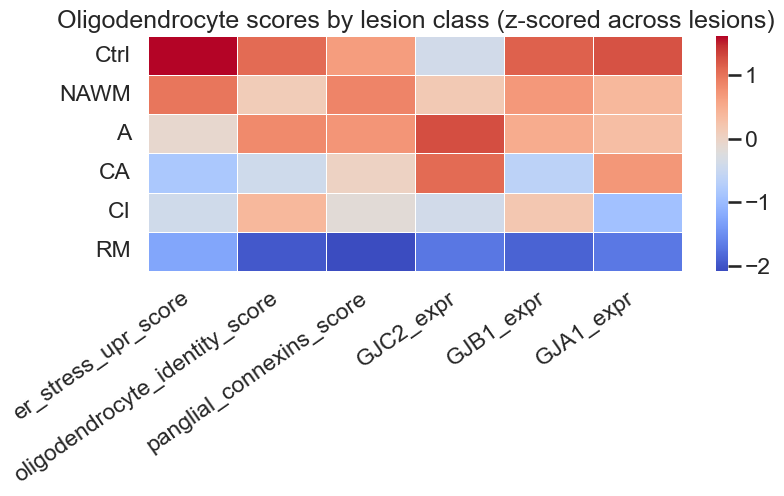

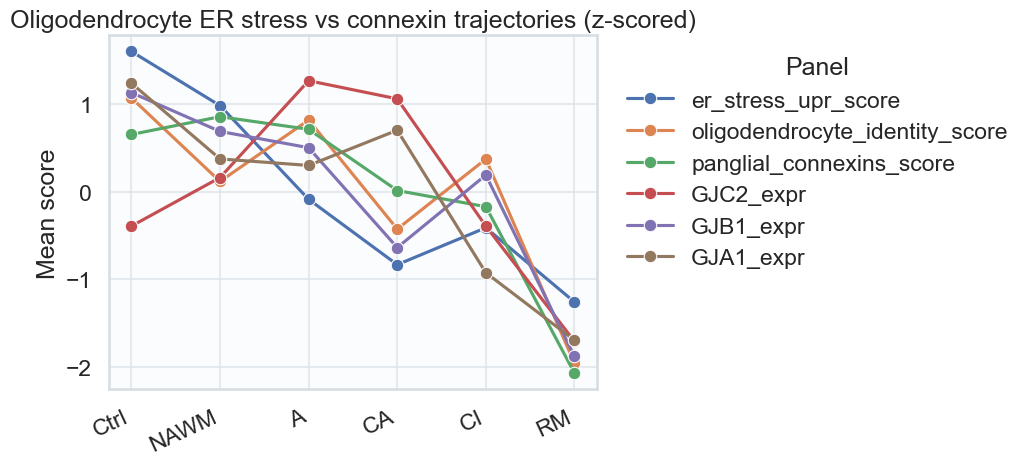

In [7]:
# Z-score across lesions for visual comparison of opposing trajectories
oligo_zscored = oligo_by_lesion.apply(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1.0))

plot_heatmap(oligo_zscored, "Oligodendrocyte scores by lesion class (z-scored across lesions)", cmap="coolwarm")
#save_current_figure(FIGURES_DIR / "oligo_scores_by_lesion_zscored.png")

plot_line_trajectories(oligo_zscored, "Oligodendrocyte ER stress vs connexin trajectories (z-scored)")
#save_current_figure(FIGURES_DIR / "oligo_trajectories_zscored.png")

## Microglial Activation by Lesion Class

We expect microglial activation to peak at Active (A) and Chronic Active (CA) lesions and decline toward Remyelinating (RM) lesions.

,microglial_activation_score,inflammatory_cytokines_score
Lesion_ordered,,
Ctrl,0.165,0.064
NAWM,0.194,-0.005
A,0.063,-0.043
CA,-0.146,0.033
CI,0.039,-0.043
RM,-0.176,-0.043


,n_cells
Celltypes,
Microglia_Macrophages,428
Macrophages,368


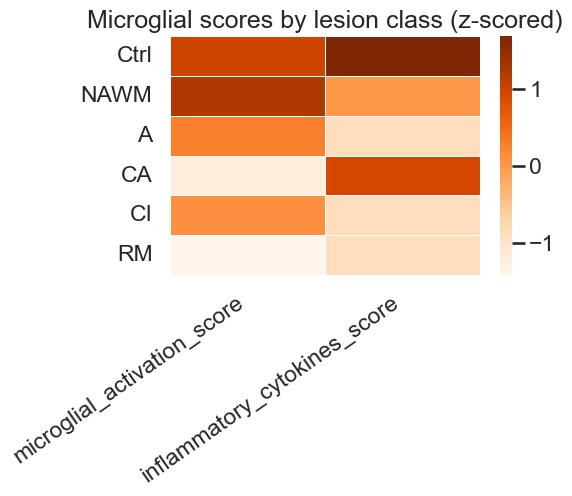

In [8]:
if adata_micro.n_obs == 0:
    display(Markdown("**No microglial/macrophage cells found** in this dataset with the current keyword filter."))
else:
    micro_scored = score_panels(adata_micro, MICROGLIA_PANELS)
    micro_score_cols = list(micro_scored.values())

    micro_by_lesion = mean_scores_by_lesion(adata_micro, micro_score_cols, lesion_order=LESION_ORDER_PRESENT)
    display(micro_by_lesion.round(3))
    save_table(micro_by_lesion, RESULTS_DIR / "microglia_scores_by_lesion.csv")

    micro_zscored = micro_by_lesion.apply(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1.0))
    plot_heatmap(micro_zscored, "Microglial scores by lesion class (z-scored)", cmap="Oranges")
    #save_current_figure(FIGURES_DIR / "microglia_scores_by_lesion_zscored.png")

    # Per-cell-type breakdown within microglia
    micro_celltypes = adata_micro.obs[CELLTYPE_COLUMN].value_counts()
    display(micro_celltypes.to_frame("n_cells"))

## Reactive Astrocyte (A1) Signatures and Ion Homeostasis by Lesion Class

A1 reactive astrocytes (marked by TNF, IL1A, C1QA, C3 co-expression context) are neurotoxic and impair gap junction coupling. We check whether these markers peak at active lesion stages.

,a1_reactive_astrocytes_score,ion_homeostasis_score,astrocyte_identity_score,GJA1_expr
Lesion_ordered,,,,
Ctrl,0.006,-0.046,0.053,1.489
NAWM,-0.053,0.336,0.180,1.619
A,0.167,0.136,0.085,1.843
CA,-0.052,-0.391,-0.323,1.810
CI,-0.067,0.178,0.037,1.583
RM,0.075,-0.434,-0.372,0.871


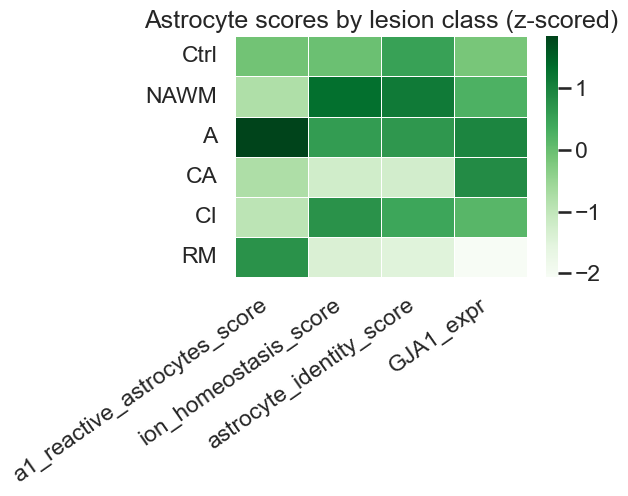

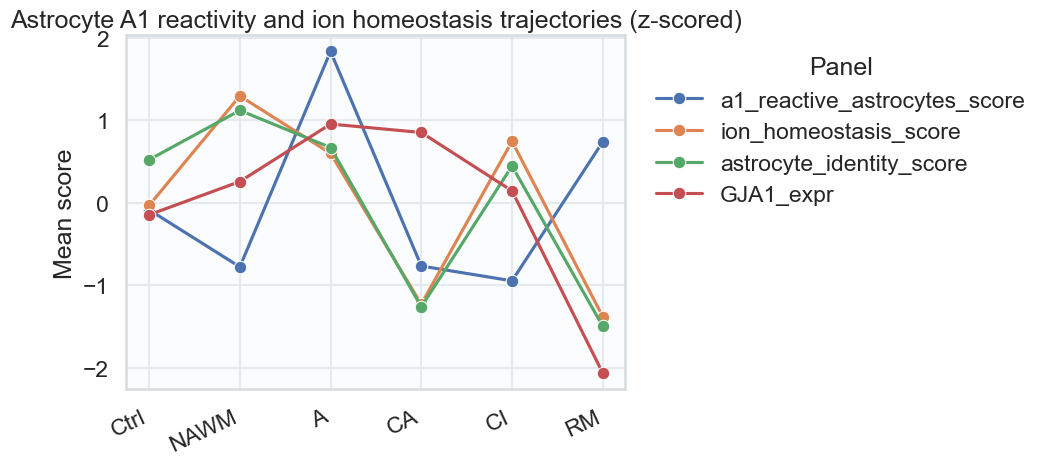

In [9]:
if adata_astro.n_obs == 0:
    display(Markdown("**No astrocyte cells found** with the current keyword filter."))
else:
    astro_scored = score_panels(adata_astro, ASTRO_PANELS)
    astro_score_cols = list(astro_scored.values())

    # Also grab GJA1 expression in astrocytes
    gja1_expr = expression_frame(adata_astro, ["GJA1"], normalize_counts=False)
    if "GJA1" in gja1_expr.columns:
        adata_astro.obs["GJA1_expr"] = gja1_expr["GJA1"].values
        astro_score_cols = astro_score_cols + ["GJA1_expr"]

    astro_by_lesion = mean_scores_by_lesion(adata_astro, astro_score_cols, lesion_order=LESION_ORDER_PRESENT)
    display(astro_by_lesion.round(3))
    save_table(astro_by_lesion, RESULTS_DIR / "astrocyte_scores_by_lesion.csv")

    astro_zscored = astro_by_lesion.apply(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1.0))
    plot_heatmap(astro_zscored, "Astrocyte scores by lesion class (z-scored)", cmap="Greens")
    #save_current_figure(FIGURES_DIR / "astrocyte_scores_by_lesion_zscored.png")

    plot_line_trajectories(astro_zscored, "Astrocyte A1 reactivity and ion homeostasis trajectories (z-scored)")
    #save_current_figure(FIGURES_DIR / "astrocyte_trajectories_zscored.png")

## Cross-Compartment Correlation: ER Stress + Reactive Glia vs Connexin Recovery

This section builds a **lesion-level summary table** by merging oligo, microglia, and astrocyte scores, then computes Spearman correlations across lesion classes. The logic is: if reactive glia drive connexin loss, we expect negative correlations between activation scores and GJC2 expression, and a positive correlation between ER stress in oligos and microglial activation.

In [10]:
frames_to_merge = []

if "oligo_by_lesion" in dir() and not oligo_by_lesion.empty:
    frames_to_merge.append(oligo_by_lesion.add_prefix("oligo__"))
if "micro_by_lesion" in dir() and not micro_by_lesion.empty:
    frames_to_merge.append(micro_by_lesion.add_prefix("micro__"))
if "astro_by_lesion" in dir() and not astro_by_lesion.empty:
    frames_to_merge.append(astro_by_lesion.add_prefix("astro__"))

if frames_to_merge:
    cross_lesion = pd.concat(frames_to_merge, axis=1).dropna(how="all")
    cross_lesion.index.name = "Lesion"
    display(cross_lesion.round(3))
    save_table(cross_lesion, RESULTS_DIR / "cross_compartment_lesion_summary.csv")
else:
    print("No compartment scores available to merge.")
    cross_lesion = pd.DataFrame()

,oligo__er_stress_upr_score,oligo__oligodendrocyte_identity_score,oligo__panglial_connexins_score,oligo__GJC2_expr,oligo__GJB1_expr,oligo__GJA1_expr,micro__microglial_activation_score,micro__inflammatory_cytokines_score,astro__a1_reactive_astrocytes_score,astro__ion_homeostasis_score,astro__astrocyte_identity_score,astro__GJA1_expr
Lesion,,,,,,,,,,,,
Ctrl,0.059,0.061,0.012,0.120,0.273,0.041,0.165,0.064,0.006,-0.046,0.053,1.489
NAWM,0.016,-0.055,0.023,0.144,0.237,0.030,0.194,-0.005,-0.053,0.336,0.180,1.619
A,-0.058,0.030,0.015,0.192,0.222,0.030,0.063,-0.043,0.167,0.136,0.085,1.843
CA,-0.109,-0.120,-0.024,0.183,0.129,0.034,-0.146,0.033,-0.052,-0.391,-0.323,1.810
CI,-0.080,-0.024,-0.034,0.120,0.197,0.015,0.039,-0.043,-0.067,0.178,0.037,1.583
RM,-0.139,-0.305,-0.140,0.063,0.028,0.006,-0.176,-0.043,0.075,-0.434,-0.372,0.871


,x,y,rho,pvalue,n
3,oligo__er_stress_upr_score,astro__a1_reactive_astrocytes_score,-0.086,0.8717,6
1,oligo__GJC2_expr,astro__a1_reactive_astrocytes_score,0.257,0.6228,6
0,oligo__GJC2_expr,micro__microglial_activation_score,0.371,0.4685,6
2,oligo__er_stress_upr_score,micro__microglial_activation_score,0.943,0.0048,6


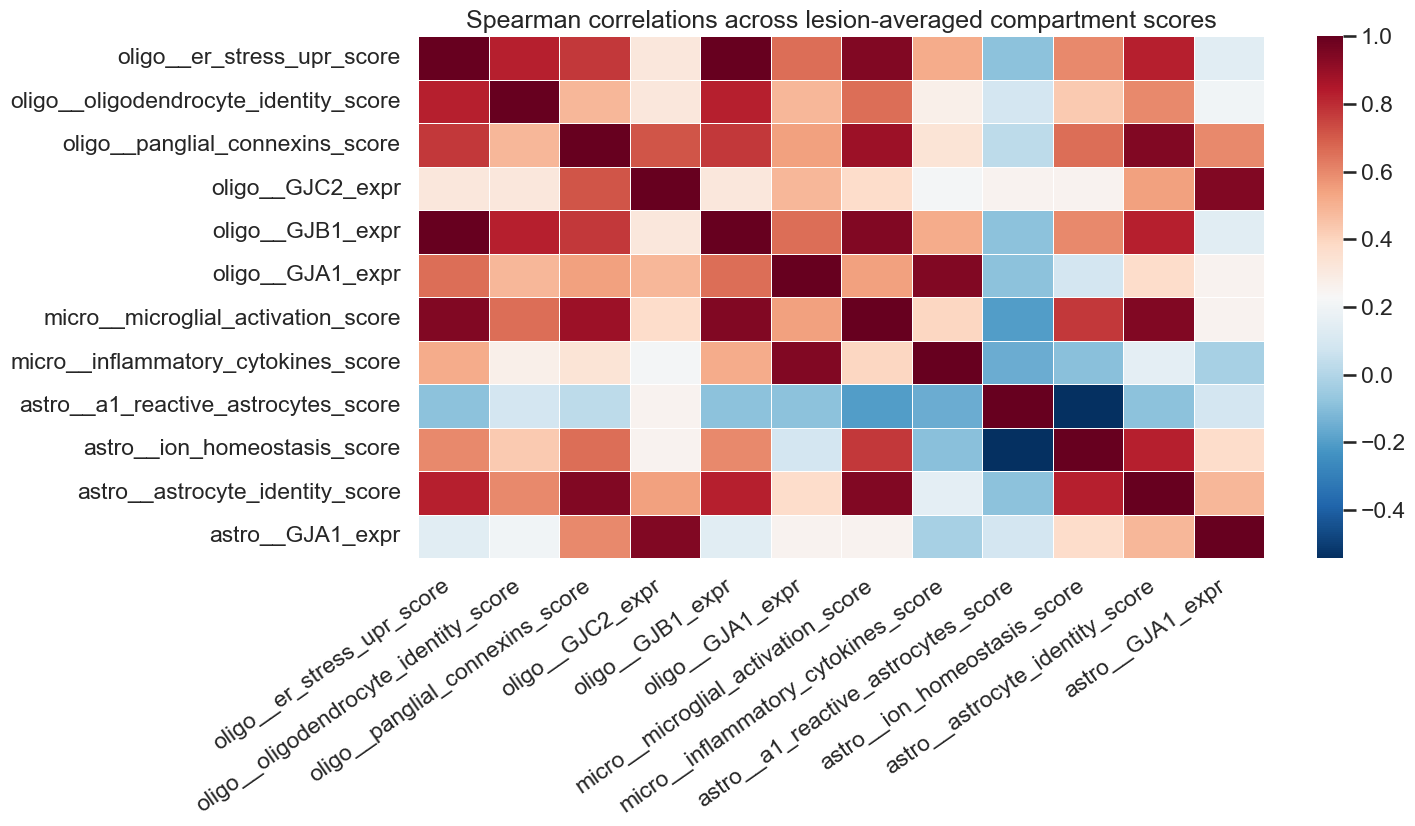

In [11]:
if not cross_lesion.empty:
    # Key hypothesis: GJC2 expression (oligo) should negatively correlate with reactive glia markers
    gjc2_col = [c for c in cross_lesion.columns if "GJC2_expr" in c]
    er_stress_col = [c for c in cross_lesion.columns if "er_stress" in c]
    micro_act_col = [c for c in cross_lesion.columns if "microglial_activation" in c]
    a1_col = [c for c in cross_lesion.columns if "a1_reactive" in c]

    x_cols = gjc2_col + er_stress_col
    y_cols = micro_act_col + a1_col + er_stress_col + gjc2_col
    y_cols = [c for c in y_cols if c not in x_cols]

    if x_cols and y_cols:
        corr_table = spearman_table(cross_lesion, x_cols, y_cols)
        display(corr_table.sort_values("rho"))
        save_table(corr_table, RESULTS_DIR / "cross_compartment_spearman.csv", index=False)
    else:
        print("Insufficient columns for cross-compartment correlation.")

    # Full correlation heatmap across all lesion-averaged scores
    corr_matrix = cross_lesion.corr(method="spearman")
    plot_heatmap(
        corr_matrix,
        "Spearman correlations across lesion-averaged compartment scores",
        cmap="RdBu_r",
    )
    #save_current_figure(FIGURES_DIR / "cross_compartment_spearman_heatmap.png")

## Donor-Level Variation

Aggregating by sample within each lesion class separates disease-stage effects from inter-donor variability.

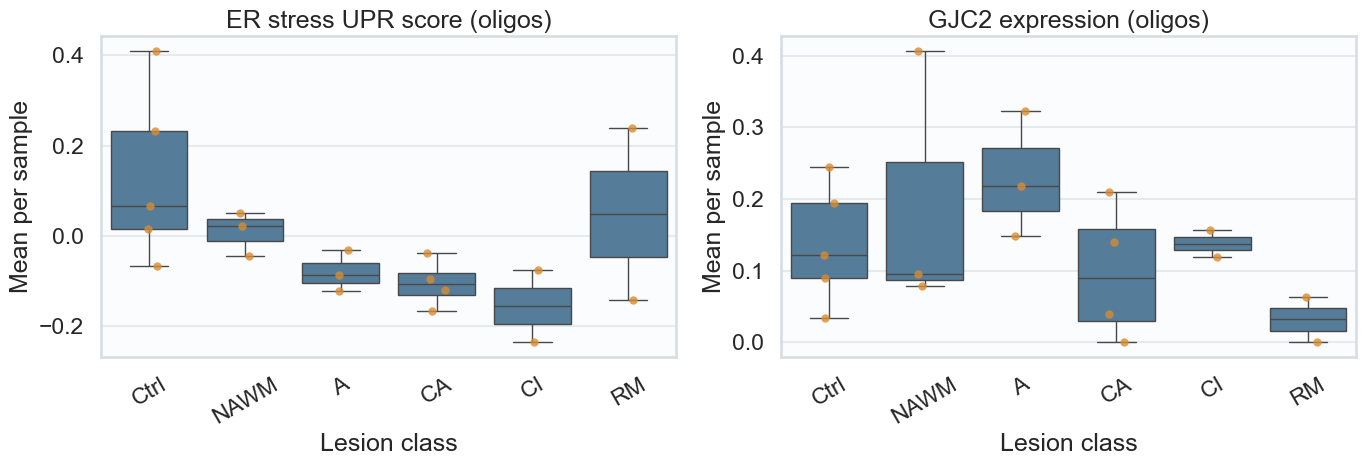

In [12]:
if "er_stress_upr_score" in adata_oligo.obs.columns:
    oligo_sample = (
        adata_oligo.obs
        .groupby(["Lesion_ordered", SAMPLE_COLUMN], observed=True)[["er_stress_upr_score", "GJC2_expr"]]
        .mean()
        .reset_index()
    )
    save_table(oligo_sample, RESULTS_DIR / "oligo_er_stress_gjc2_sample_means.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, label in zip(
        axes,
        ["er_stress_upr_score", "GJC2_expr"],
        ["ER stress UPR score (oligos)", "GJC2 expression (oligos)"],
    ):
        sns.boxplot(data=oligo_sample, x="Lesion_ordered", y=col, ax=ax, showfliers=False, color="#4a7fa5")
        sns.stripplot(data=oligo_sample, x="Lesion_ordered", y=col, ax=ax, color="#d88c32", alpha=0.8, size=6)
        ax.set_title(label)
        ax.set_xlabel("Lesion class")
        ax.set_ylabel("Mean per sample")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    #save_current_figure(FIGURES_DIR / "oligo_er_stress_gjc2_by_sample_lesion.png")

## Secondary Dataset: Falcao et al. (EAE)

The Falcao dataset provides an EAE time-resolved view. If `stage` metadata is available, we repeat the key analyses using disease stage as the progression axis. This cross-validates whether the lesion-class patterns in Jäkel align with EAE dynamics.

In [13]:
FALCAO_PATH = REPO_ROOT / "data" / "raw" / "falcao_et_al.h5ad"

if not FALCAO_PATH.exists():
    display(Markdown(f"**Falcao dataset not found** at `{FALCAO_PATH}`. Skipping secondary analysis."))
    adata_fal = None
else:
    adata_fal = load_h5ad(FALCAO_PATH)
    display(adata_overview(adata_fal))

    fal_stage_col = next((c for c in adata_fal.obs.columns if "stage" in c.lower()), None)
    fal_ct_col = next(
        (c for c in adata_fal.obs.columns if any(k in c.lower() for k in ["anno", "celltype", "cell_type", "cluster", "label"])),
        None,
    )
    print("Stage column:", fal_stage_col)
    print("Cell type column:", fal_ct_col)

    fal_coverage = panel_availability_table(adata_fal, ALL_PANELS)
    display(fal_coverage)
    save_table(fal_coverage, RESULTS_DIR / "falcao_panel_coverage.csv", index=False)

,metric,value
0,n_obs,1765
1,n_vars,18357
2,obs_columns,50
3,var_columns,2
4,layers,(none)
5,obsm,(none)
6,uns_keys,"source_dataset, source_stats"
7,raw_present,False


Stage column: None
Cell type column: Clusters


,panel,panel_size,present_count,missing_count,coverage,present_genes,missing_genes
0,a1_reactive_astrocytes,4,4,0,1.000,"TNF, IL1A, C1QA, C3",
1,astrocyte_identity,5,5,0,1.000,"GFAP, AQP4, ALDH1L1, SLC1A2, SLC1A3",
2,er_stress_upr,6,6,0,1.000,"ERP29, ATF4, XBP1, DDIT3, HSPA5, EIF2AK3",
3,inflammatory_cytokines,6,6,0,1.000,"TNF, IL1B, IL6, CCL2, CXCL10, CSF2",
4,ion_homeostasis,4,4,0,1.000,"KCNJ10, ATP1A2, SLC1A2, SLC1A3",
5,oligodendrocyte_identity,10,9,1,0.900,"MBP, MOG, PLP1, MAG, CNP, SOX10, OLIG2, MYRF, ...",NKX2-2
6,microglial_activation,7,6,1,0.857,"NOS2, CD68, ITGAM, AIF1, C1QA, C3",HLA-DRA
7,panglial_connexins,6,5,1,0.833,"GJC2, GJB1, GJC3, GJA1, GJB6",GJD2


Falcao — Oligos: 299  Microglia: 0  Astrocytes: 0


**Falcao oligo scores by Clusters:**

,er_stress_upr_score,oligodendrocyte_identity_score,panglial_connexins_score
Clusters,,,
OPC.cluster1_Neu4_Igsf21_Ptprz1_1,0.312,0.707,0.006
OPC.cluster1_Neu4_Igsf21_Ptprz1_2,-0.011,-0.250,-0.091
OPC.cluster1_Neu4_Igsf21_Ptprz1_3,-0.253,-0.084,-0.009
OPC.cluster1_Neu4_Igsf21_Ptprz1_5,0.064,-0.478,-0.183
OPC.cluster1_Neu4_Igsf21_Ptprz1_6,0.139,1.514,0.703
OPC.cluster1_Neu4_Igsf21_Ptprz1_8,0.016,-0.070,0.101


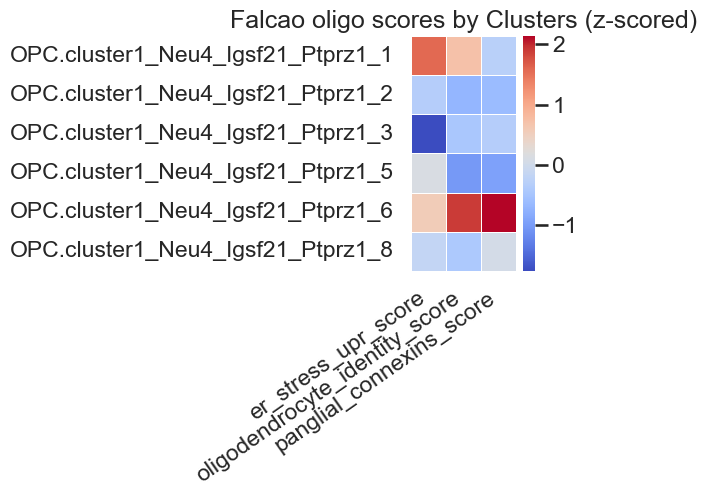

In [14]:
if adata_fal is not None and fal_ct_col is not None:
    fal_oligo_mask = obs_keyword_mask(adata_fal, fal_ct_col, ["oligo", "opc", "cop"])
    fal_micro_mask = obs_keyword_mask(adata_fal, fal_ct_col, ["microglia", "macrophage", "myeloid"])
    fal_astro_mask = obs_keyword_mask(adata_fal, fal_ct_col, ["astro"])

    fal_adata_oligo = adata_fal[fal_oligo_mask].copy()
    fal_adata_micro = adata_fal[fal_micro_mask].copy()
    fal_adata_astro = adata_fal[fal_astro_mask].copy()

    print(f"Falcao — Oligos: {fal_adata_oligo.n_obs}  Microglia: {fal_adata_micro.n_obs}  Astrocytes: {fal_adata_astro.n_obs}")

    GROUP_COL = fal_stage_col if fal_stage_col else fal_ct_col

    fal_results = {}
    for label, subset, panels in [
        ("oligo", fal_adata_oligo, OLIGO_PANELS),
        ("microglia", fal_adata_micro, MICROGLIA_PANELS),
        ("astrocyte", fal_adata_astro, ASTRO_PANELS),
    ]:
        if subset.n_obs == 0:
            continue
        scored = score_panels(subset, panels)
        if GROUP_COL in subset.obs.columns and scored:
            by_group = subset.obs.groupby(GROUP_COL, observed=True)[list(scored.values())].mean()
            fal_results[label] = by_group
            display(Markdown(f"**Falcao {label} scores by {GROUP_COL}:**"))
            display(by_group.round(3))
            save_table(by_group, RESULTS_DIR / f"falcao_{label}_scores_by_{GROUP_COL}.csv")

            by_group_z = by_group.apply(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1.0))
            plot_heatmap(by_group_z, f"Falcao {label} scores by {GROUP_COL} (z-scored)", cmap="coolwarm")
            #save_current_figure(FIGURES_DIR / f"falcao_{label}_scores_by_{GROUP_COL}_zscored.png")